# 01. Dataset Audit

This notebook performs a rigorous audit of the Flood Water Segmentation dataset:
1. **File integrity & pair matching** (images vs labels, ignoring `X_Y.png` duplicate artifacts).
2. **Image dimensions, dtypes, and channels** (128x128x12 `int16`).
3. **Binary mask integrity** (128x128 `uint8`, {0, 1} strictly).
4. **Per-band statistics & NoData verification** (-9999 in Band 8 only; valid negative reflectance in Bands 0-6).
5. **Class distribution** (water pixel ratio per image).
6. **Elevation clustering** for group-aware splitting.

In [4]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Ensure project root is in sys.path
for candidate in [Path.cwd(), Path.cwd().parent, Path('e:/Cellula_Technologies/Project2/water_segmentation')]:
    if (candidate / 'data' / 'raw' / 'images').exists() and (candidate / 'src').exists():
        project_root = candidate
        break
    elif (candidate / 'water_segmentation' / 'data' / 'raw' / 'images').exists():
        project_root = candidate / 'water_segmentation'
        break
else:
    project_root = Path('e:/Cellula_Technologies/Project2/water_segmentation')

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import tifffile
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.paths import get_data_dirs, resolve_file
from src.data.audit import run_dataset_audit


## 1. Run Complete Audit
Auditing 306 satellite scenes and ground truth binary masks.

In [5]:
img_dir, lbl_dir, splits_dir, stats_dir, checkpoints_dir = get_data_dirs()
print(f"Resolved Image Dir: {img_dir}")
print(f"Resolved Label Dir: {lbl_dir}")

summary, df_audit = run_dataset_audit(img_dir, lbl_dir)

print(f"Total Expected:      {summary['total_expected']}")
print(f"Valid Pairs:         {summary['valid_pairs']}")
print(f"Missing Images:      {len(summary['missing_images'])}")
print(f"Missing Labels:      {len(summary['missing_labels'])}")
print(f"Corrupted Files:     {len(summary['corrupted_files'])}")
print(f"Extra X_Y.png:       {summary['extra_xy_labels_count']} (IGNORED duplicate copies)")
print(f"Mean Water Ratio:    {summary['mean_water_ratio']:.2%}")
print(f"Median Water Ratio:  {summary['median_water_ratio']:.2%}")
print(f"Zero-water Images:   {summary['empty_water_images']}")
print(f"Majority-water:      {summary['majority_water_images']}")


Resolved Image Dir: ..\data\raw\images
Resolved Label Dir: ..\data\raw\labels
Total Expected:      306
Valid Pairs:         306
Missing Images:      0
Missing Labels:      0
Corrupted Files:     0
Extra X_Y.png:       150 (IGNORED duplicate copies)
Mean Water Ratio:    25.98%
Median Water Ratio:  16.45%
Zero-water Images:   45
Majority-water:      66


## 2. Per-Band Summary Statistics Table
Notice that Band 8 (Merit DEM) has -9999 NoData pixels. Bands 0-6 have negative minimums which are valid atmospheric corrected reflectances.

In [6]:
stats_df = pd.DataFrame({
    "Band": [f"B{i:02d}" for i in range(12)],
    "Name": summary["band_names"],
    "Min": [round(x, 1) for x in summary["band_mins"]],
    "Max": [round(x, 1) for x in summary["band_maxs"]],
    "Mean": [round(x, 1) for x in summary["band_means"]],
    "Std": [round(x, 1) for x in summary["band_stds"]],
    "NoData (-9999) Pixels": summary["band_nodata_counts"],
})
stats_df

,Band,Name,Min,Max,Mean,Std,NoData (-9999) Pixels
0,B00,Coastal Aerosol,-1393.0,6568.0,396.5,270.1,0
1,B01,Blue,-1169.0,9659.0,494.6,326.0,0
2,B02,Green,-722.0,11368.0,822.3,418.1,0
3,B03,Red,-684.0,12041.0,973.7,586.7,0
4,B04,NIR,-412.0,15841.0,2090.1,1056.0,0
5,B05,SWIR1,-335.0,15252.0,1964.1,1191.4,0
6,B06,SWIR2,-258.0,14647.0,1351.3,961.8,0
7,B07,QA Band,64.0,255.0,102.7,48.8,0
8,B08,Merit DEM,-1.0,4245.0,301.4,498.1,77704
9,B09,Copernicus DEM,8.0,4287.0,300.7,496.0,0


## 3. Water Ratio Distribution
Analyzing the class distribution across the 306 scenes.

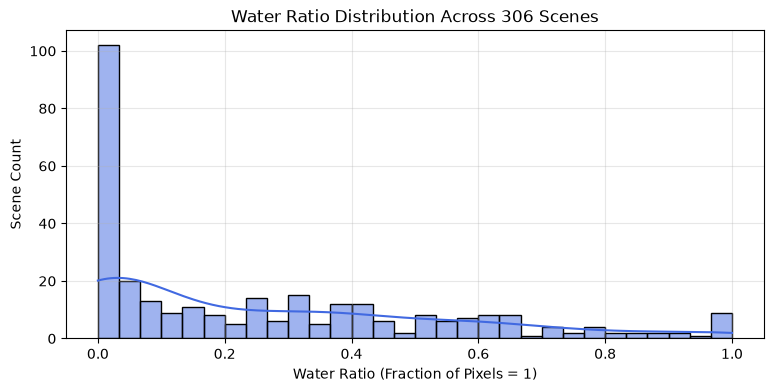

In [7]:
plt.figure(figsize=(9, 4))
sns.histplot(df_audit["water_ratio"], bins=30, kde=True, color="royalblue")
plt.title("Water Ratio Distribution Across 306 Scenes")
plt.xlabel("Water Ratio (Fraction of Pixels = 1)")
plt.ylabel("Scene Count")
plt.grid(True, alpha=0.3)
plt.show()

## 4. DEM Elevation Clusters
Elevation distribution used for group-aware splitting.

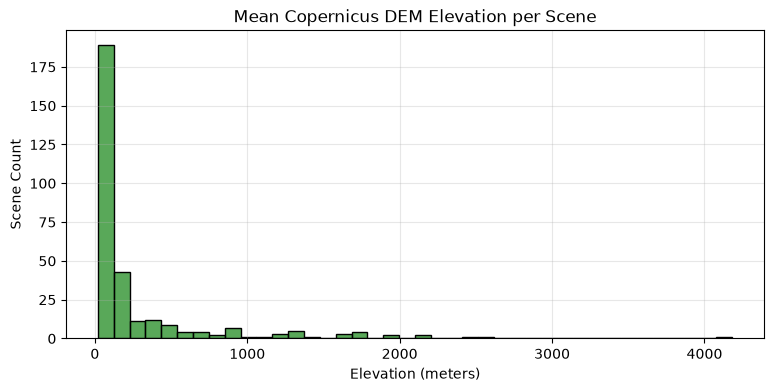

In [8]:
plt.figure(figsize=(9, 4))
sns.histplot(df_audit["copernicus_mean"], bins=40, color="forestgreen")
plt.title("Mean Copernicus DEM Elevation per Scene")
plt.xlabel("Elevation (meters)")
plt.ylabel("Scene Count")
plt.grid(True, alpha=0.3)
plt.show()